In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
uf = pd.read_csv("A:\\AIML_DEV_FOLDER\\Dataset_self\\diabetes.csv")

In [3]:
uf.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
df=uf[['Pregnancies','Glucose','BloodPressure',	'SkinThickness'	,'Insulin',	'BMI','DiabetesPedigreeFunction','Age',	'Outcome'
]]

# i am only picking up the numbercial  id 


In [5]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


# drop missing value 

In [6]:
df.dropna()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


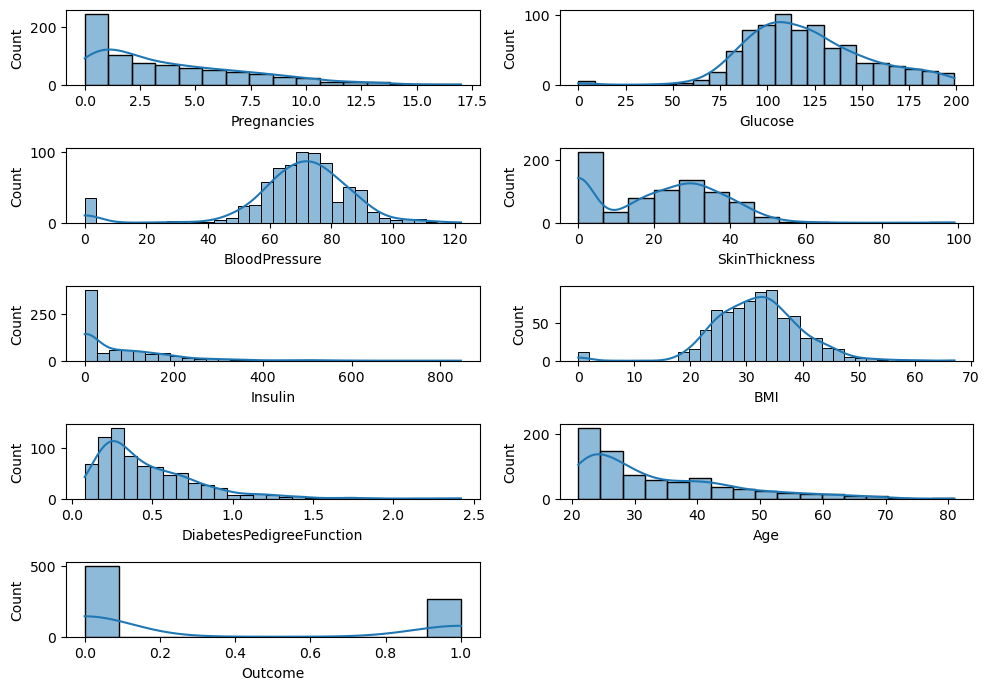

In [7]:
col =   ['Pregnancies','Glucose','BloodPressure',	'SkinThickness'	,'Insulin',	'BMI','DiabetesPedigreeFunction','Age',	'Outcome'
]
plt.figure(figsize=(10,7))
for i, col in enumerate(col,1 ):
    plt.subplot(5,2,i)
    sns.histplot(df[col],kde=True)
plt.tight_layout()
plt.show()

# data review 
 *  we will not inclye the last one due to reason 
 

In [8]:
df=df[['Pregnancies','Glucose','BloodPressure',	'SkinThickness'	,'Insulin',	'BMI','DiabetesPedigreeFunction','Age',]]

In [9]:
df['Pregnancies'].describe()

count    768.000000
mean       3.845052
std        3.369578
min        0.000000
25%        1.000000
50%        3.000000
75%        6.000000
max       17.000000
Name: Pregnancies, dtype: float64

3 while pr

<Axes: xlabel='Pregnancies'>

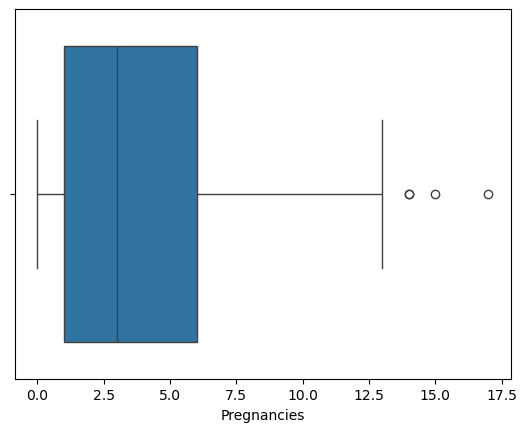

In [10]:
sns.boxplot(x=df['Pregnancies'])

From above image we can see that there are some outlier in the right side 

# As per rule we will calculate the percentile 

In [11]:
percentile25 = df["Pregnancies"].quantile(0.025)

percentile75 = df["Pregnancies"].quantile(0.75)
print(percentile25, percentile75)

0.0 6.0


 * Now our data is set 
 as we high and low 

# iqr = Q3 - Q1

In [12]:
iqr = percentile75-percentile25
iqr

np.float64(6.0)

## finding upper and lower limit 


In [13]:
upperlimt = percentile75 + 1.5*iqr
lowerlimt = percentile25 - 1.5*iqr
print(upperlimt, lowerlimt)

15.0 -9.0


# Find the outlier 

In [14]:
df[df['Pregnancies'] > upperlimt]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
159,17,163,72,41,114,40.9,0.817,47


In [15]:
df[df['Pregnancies'] < lowerlimt]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age


In [16]:
new_trim= df[df['Pregnancies']<upperlimt] # will remove it 17 pregnancies 

# look this diffrence 


In [17]:
print(new_trim.shape,df.shape)


(766, 8) (768, 8)


<Axes: xlabel='Pregnancies'>

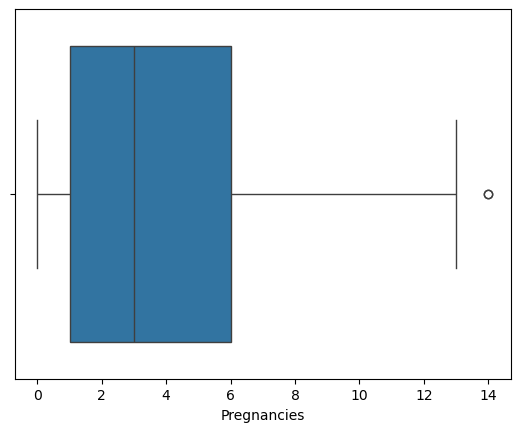

In [18]:
sns.boxplot(x = new_trim["Pregnancies"])

<Axes: xlabel='Pregnancies'>

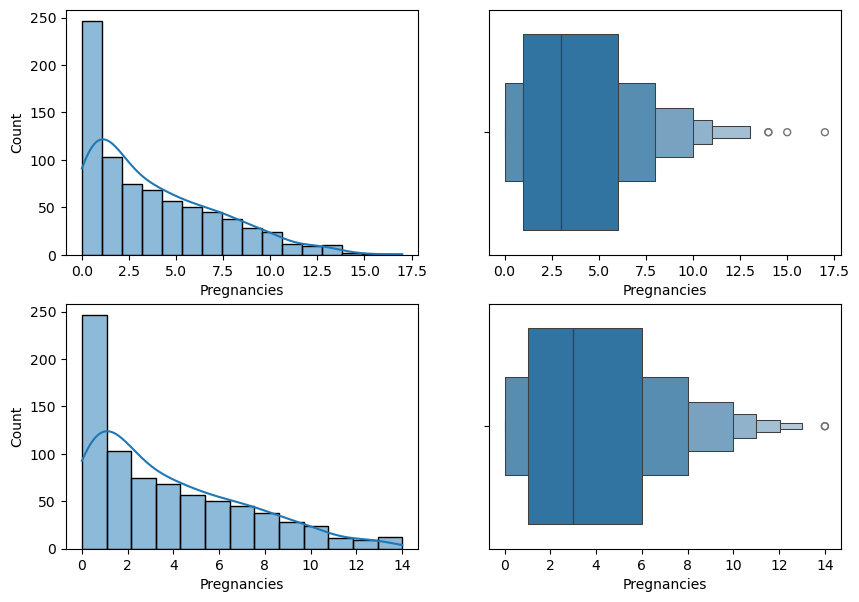

In [19]:
plt.figure(figsize=(10,7))

plt.subplot(2,2,1)
sns.histplot(df["Pregnancies"],kde=True)

plt.subplot(2,2,2)
sns.boxenplot(x=df['Pregnancies'])

plt.subplot(2,2,3)
sns.histplot(new_trim["Pregnancies"],kde=True)

plt.subplot(2,2,4)
sns.boxenplot(x=new_trim['Pregnancies'])


# Capping 

In [20]:
new_df_cap = df.copy()
new_df_cap["Pregnancies"] = np.where(new_df_cap["Pregnancies"]>upperlimt, upperlimt,  
np.where(
    new_df_cap["Pregnancies"]<lowerlimt, lowerlimt,
    new_df_cap["Pregnancies"]         
)
)

<Axes: xlabel='Pregnancies'>

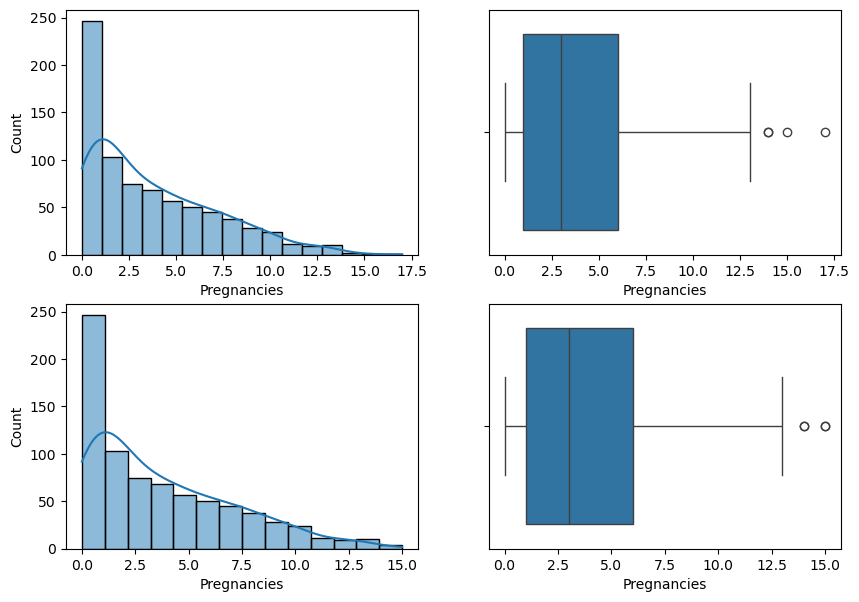

In [21]:
plt.figure(figsize=(10,7))

plt.subplot(2,2,1)
sns.histplot(df['Pregnancies'],kde=True)

plt.subplot(2,2,2)
sns.boxplot(x = df['Pregnancies'])

plt.subplot(2,2,3)
sns.histplot(new_df_cap["Pregnancies"],kde=True)

plt.subplot(2,2,4)
sns.boxplot(x=new_df_cap['Pregnancies'])

# 'Glucose'

In [22]:
df['Glucose'].describe()

count    768.000000
mean     120.894531
std       31.972618
min        0.000000
25%       99.000000
50%      117.000000
75%      140.250000
max      199.000000
Name: Glucose, dtype: float64

<Axes: xlabel='Glucose'>

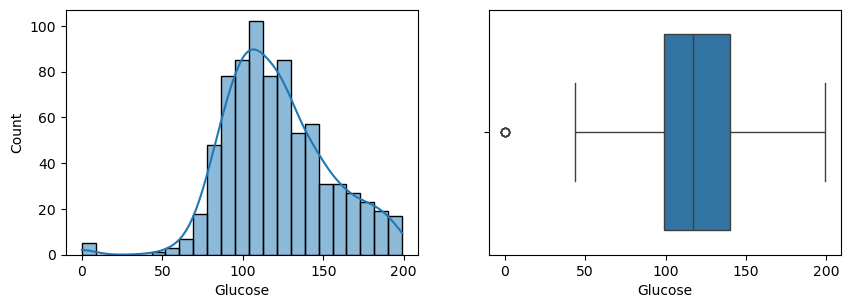

In [23]:
plt.figure(figsize=(10,7))

plt.subplot(2,2,1)
sns.histplot(df['Glucose'],kde=True)

plt.subplot(2,2,2)
sns.boxplot(x = df['Glucose'])

In [24]:
percentile25 = df['Glucose'].quantile(0.25)
percentile75 = df['Glucose'].quantile(0.75)
print(percentile25,percentile75)

99.0 140.25


In [25]:
iqr = percentile75-  percentile25 
iqr

np.float64(41.25)

In [26]:
upperlimt = percentile75 + 1.5*iqr
lowerlimt = percentile25-1.5*iqr
print(upperlimt, lowerlimt)


202.125 37.125


In [27]:
print(upperlimt)
print(lowerlimt)

202.125
37.125


## finding the outlier in Glucose 

In [28]:
df[df['Glucose'] > upperlimt]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age


In [29]:
df[df['Glucose'] < lowerlimt]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
75,1,0,48,20,0,24.7,0.140,22
182,1,0,74,20,23,27.7,0.299,21
342,1,0,68,35,0,32.0,0.389,22
349,5,0,80,32,0,41.0,0.346,37
502,6,0,68,41,0,39.0,0.727,41


In [30]:
new_trim = df[df['Glucose']<upperlimt] # 0 removal 

In [31]:
new_trim = df[df['Glucose']>lowerlimt] # 5 removal 

In [32]:
print('old df', df.shape, "new trimmed",new_trim.shape)

old df (768, 8) new trimmed (763, 8)


<Axes: xlabel='Glucose'>

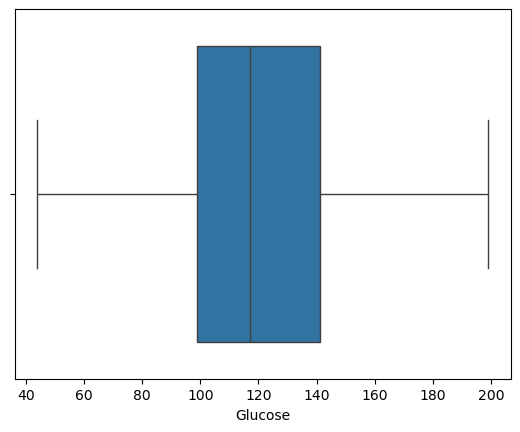

In [33]:
sns.boxplot(x=new_trim['Glucose'])

C:\Users\manis\AppData\Local\Temp\ipykernel_20640\1275917128.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Glucose'])
C:\Users\manis\AppData\Local\Temp\ipykernel_20640\1275917128.py:11: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_trim['Glucose'])


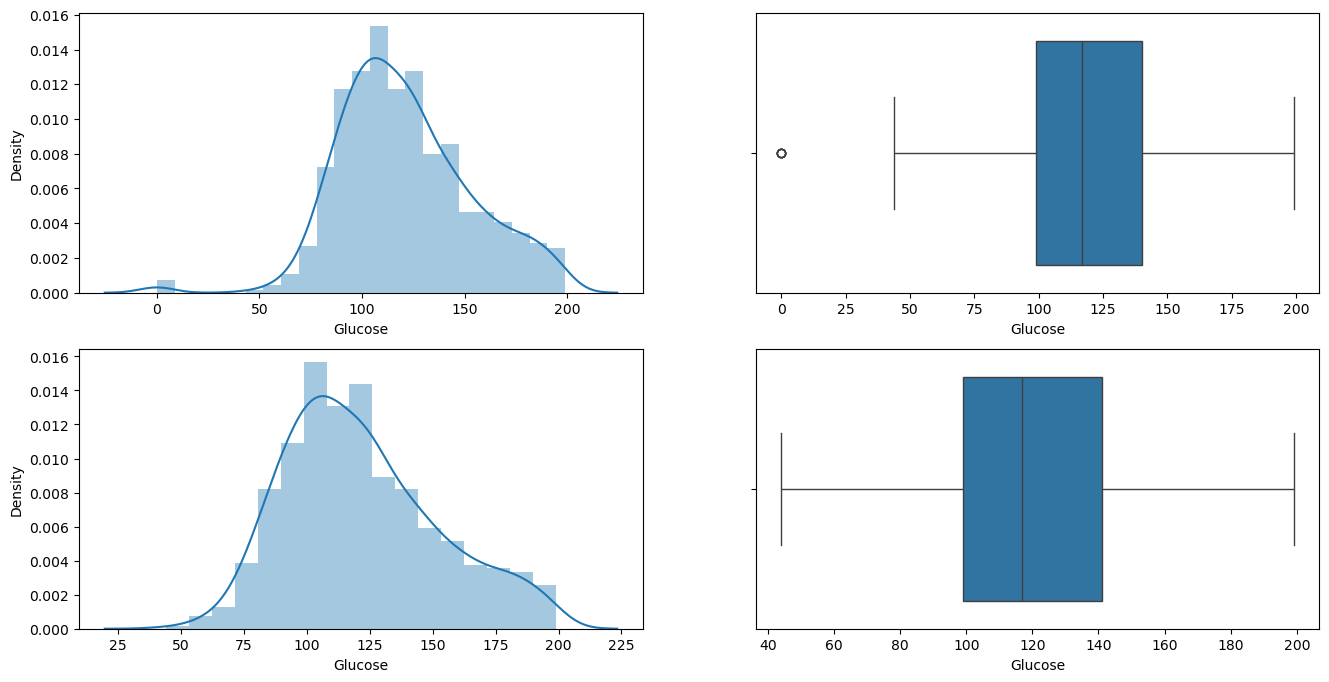

In [34]:
# Comparing

plt.figure(figsize=(16,8)) # figure size
plt.subplot(2,2,1) # plot number
sns.distplot(df['Glucose'])

plt.subplot(2,2,2)
sns.boxplot(x=df['Glucose'])

plt.subplot(2,2,3)
sns.distplot(new_trim['Glucose'])

plt.subplot(2,2,4)
sns.boxplot(x=new_trim['Glucose'])

plt.show()

# Capping 

In [35]:
new_cap_glu = df.copy()
new_cap_glu['Glucose'] = np.where(
    new_cap_glu['Glucose'] > upperlimt, upperlimt,
    np.where(
        new_cap_glu['Glucose'] < lowerlimt, lowerlimt,
        new_cap_glu["Glucose"]
    )
)

C:\Users\manis\AppData\Local\Temp\ipykernel_20640\2752665188.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Glucose'])
C:\Users\manis\AppData\Local\Temp\ipykernel_20640\2752665188.py:11: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_trim['Glucose'])


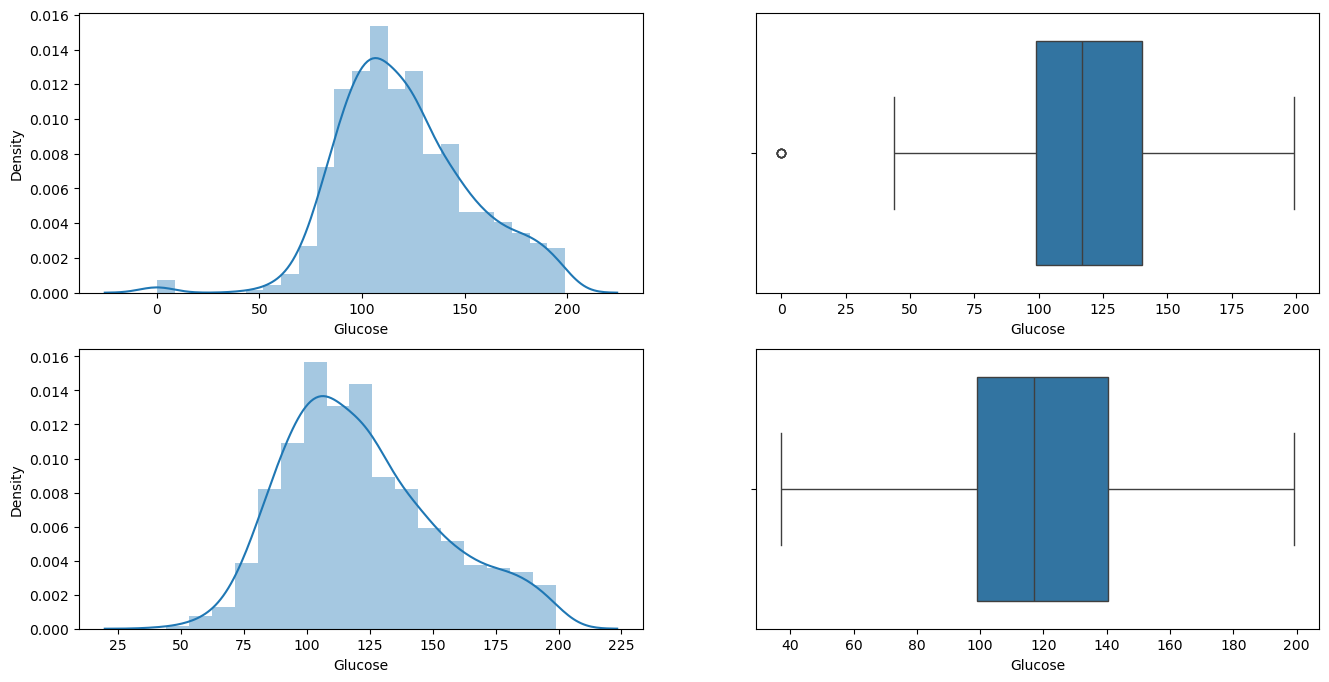

In [36]:
# Comparing

plt.figure(figsize=(16,8)) # figure size
plt.subplot(2,2,1) # plot number
sns.distplot(df['Glucose'])

plt.subplot(2,2,2)
sns.boxplot(x=df['Glucose'])

plt.subplot(2,2,3)
sns.distplot(new_trim['Glucose'])

plt.subplot(2,2,4)
sns.boxplot(x=new_cap_glu['Glucose'])

plt.show()

In [37]:
Aper75 = []
Aper25 = []
col = ['BloodPressure',	'SkinThickness'	,'Insulin',	'BMI','DiabetesPedigreeFunction','Age']
for i in col :
    Aper75.append(df[i].quantile(0.75))
    Aper25.append(df[i].quantile(0.25))    


In [38]:
Aper25

[np.float64(62.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(27.3),
 np.float64(0.24375),
 np.float64(24.0)]

In [39]:
columns = ['BloodPressure',	'SkinThickness'	,'Insulin',	'BMI','DiabetesPedigreeFunction','Age']
iqr = []
for i,  col in enumerate(columns):
    iqr_value=(Aper75[i]-Aper25[i])
    iqr.append(iqr_value )

In [40]:
print('iqr_',iqr)
iqr

iqr_ [np.float64(18.0), np.float64(32.0), np.float64(127.25), np.float64(9.3), np.float64(0.38249999999999995), np.float64(17.0)]


[np.float64(18.0),
 np.float64(32.0),
 np.float64(127.25),
 np.float64(9.3),
 np.float64(0.38249999999999995),
 np.float64(17.0)]

In [41]:
Aupperlimt =[]
Alowerlimt =[]
for i,  col in enumerate(columns):
    upperlimit = Aper75[i]+1.5*iqr[i]
    lowerlimit = Aper25[i]-1.5*iqr[i]
    Aupperlimt.append(upperlimit)
    Alowerlimt.append(lowerlimit)
Alowerlimt

[np.float64(35.0),
 np.float64(-48.0),
 np.float64(-190.875),
 np.float64(13.35),
 np.float64(-0.32999999999999996),
 np.float64(-1.5)]

In [42]:
Aupperlimt

[np.float64(107.0),
 np.float64(80.0),
 np.float64(318.125),
 np.float64(50.550000000000004),
 np.float64(1.2),
 np.float64(66.5)]

In [43]:
adf=df.copy()
columns = ['BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
for i,  col in enumerate(columns):
    adf[col]=np.where(
        adf[col]>Aupperlimt[i], Aupperlimt[i],
        np.where(
            adf[col]<Alowerlimt[i],Alowerlimt[i],
            adf[col]   
            )
        )

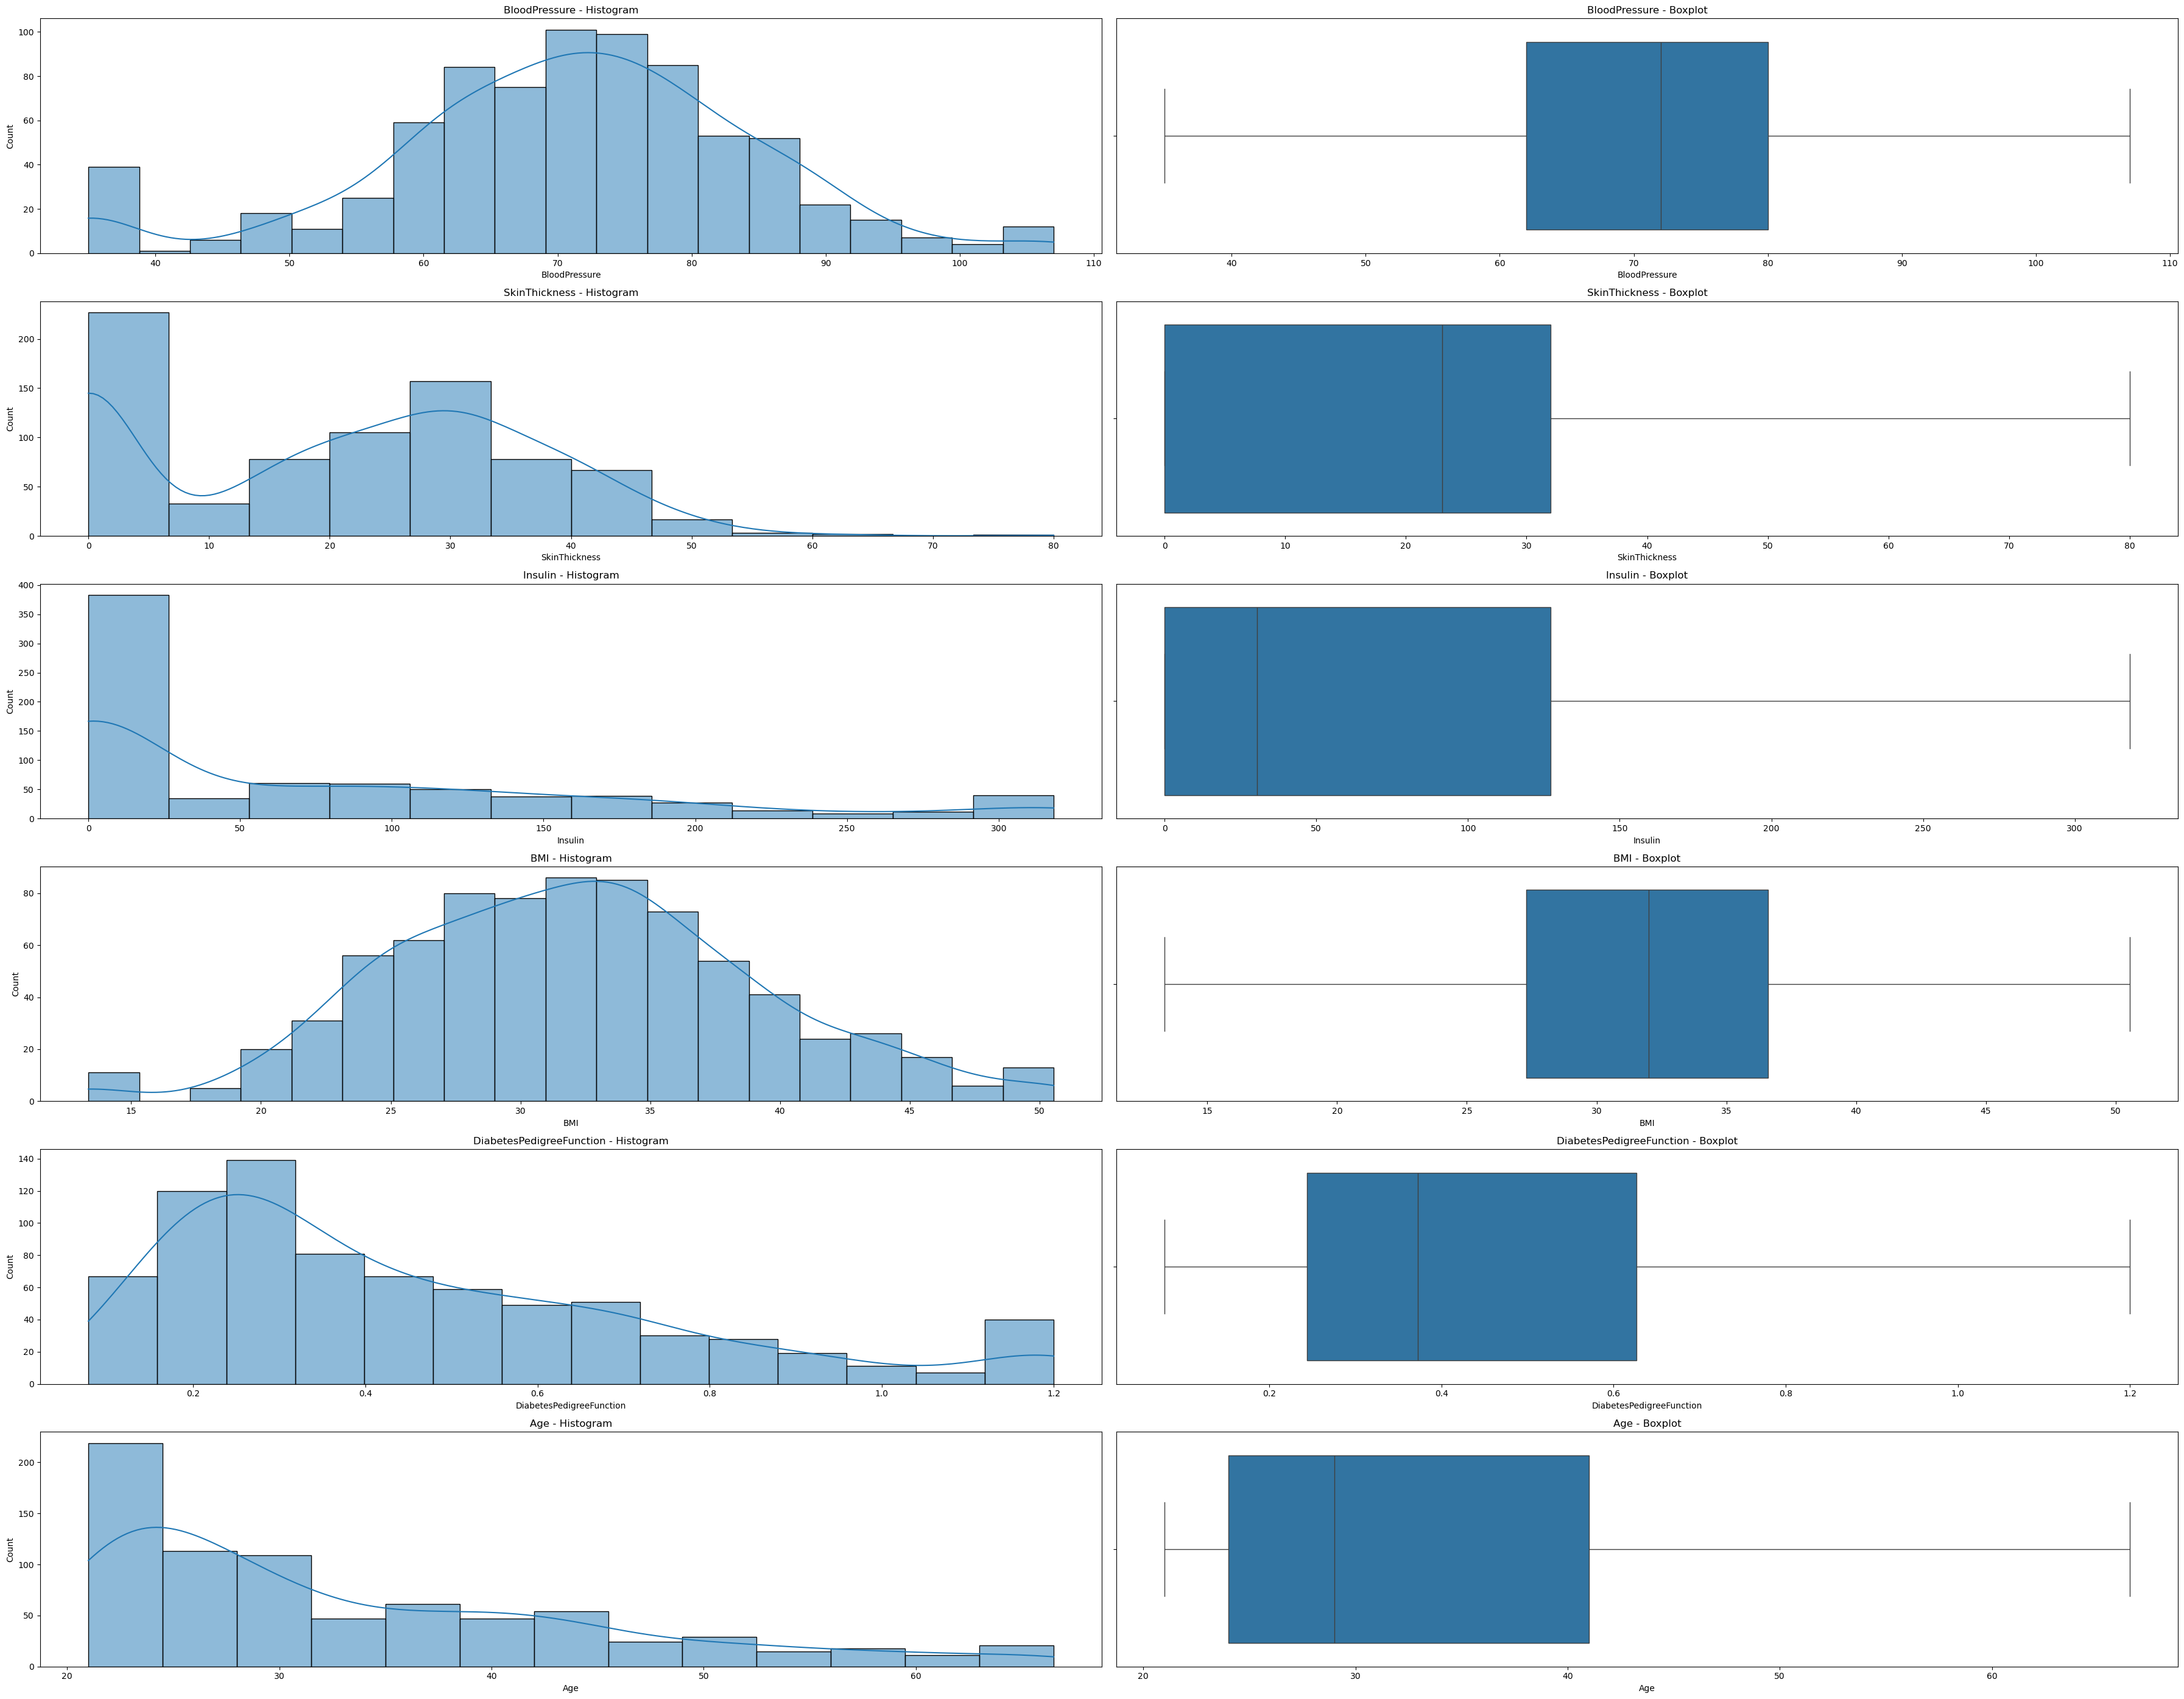

In [44]:
columns = ['BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
plt.figure(figsize=(36,28))
for i , col in enumerate(columns):
        # Histogram
    plt.subplot(6, 2, i*2 + 1) # 3 rows, 4 columns, odd positions
    sns.histplot(adf[col], kde=True)
    plt.title(f'{col} - Histogram')
    
    # Boxplot
    plt.subplot(6, 2, i*2 + 2)  # 3 rows, 4 columns, even positions
    sns.boxplot(x=adf[col])
    plt.title(f'{col} - Boxplot')
plt.tight_layout()
plt.show()
